# Analysis of Barren Plateau Mitigation Techniques with Qubit Scaling

This implementation analyzes barren plateau behavior across different system sizes
by running VQE experiments with varying numbers of qubits.

Key Features:
- Runs experiments for multiple qubit numbers
- Analyzes variance scaling with system size
- Compares all VQE methods across different scales
- Generates comprehensive scaling plots


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.append("./../")

from src.barren_plateau_analyzer import BarrenPlateauAnalyzer
from qubap.qiskit.state_efficient_ansatz import ansatz_constructor
from qiskit.circuit.library import EfficientSU2

In [2]:
# Configuration
FIXED_NUM_QUBITS = 6  # Fixed system size
LAYER_RANGE = [1, 2, 3, 4, 5, 6]  # Vary ansatz depth
NUM_ITERATIONS = 1000
PLOTS_DIR = "./layer_scaling_analysis"

print("=" * 70)
print("VQE BARREN PLATEAU LAYER SCALING ANALYSIS")
print("=" * 70)
print(f"Fixed qubits: {FIXED_NUM_QUBITS}")
print(f"Layer range: {LAYER_RANGE}")
print(f"Iterations: {NUM_ITERATIONS}")
print(f"Output: {PLOTS_DIR}")

Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

VQE BARREN PLATEAU LAYER SCALING ANALYSIS
Fixed qubits: 6
Layer range: [1, 2, 3, 4, 5, 6]
Iterations: 1000
Output: ./layer_scaling_analysis


In [3]:
def create_multi_layer_sea_ansatz(num_qubits, num_layers):
    """Create multi-layer SEA ansatz by repeating the basic structure."""
    print(f"   Creating {num_layers}-layer SEA ansatz for {num_qubits} qubits...")
    
    # Try different approaches for multi-layer construction
    approaches = [
        # Approach 1: Repeat the deep config num_layers times
        lambda: create_repeated_deep_config(num_qubits, num_layers),
        # Approach 2: Single deep config with layer count
        lambda: create_single_deep_config(num_qubits, num_layers),
        # Approach 3: EfficientSU2 with layer control
        lambda: create_efficient_su2_layers(num_qubits, num_layers)
    ]
    
    for i, approach in enumerate(approaches):
        try:
            ansatz = approach()
            print(f"     Success with approach {i+1}: {ansatz.num_parameters} parameters")
            return ansatz
        except Exception as e:
            print(f"     Approach {i+1} failed: {e}")
            continue
    
    # Final fallback
    print(f"    Using simple EfficientSU2 fallback...")
    return EfficientSU2(num_qubits, ["ry", "rz"], "linear", num_layers)

def create_repeated_deep_config(num_qubits, num_layers):
    """Create ansatz by repeating basic layer structure."""
    # For multi-layer, we can try repeating the construction
    if num_layers == 1:
        return ansatz_constructor(num_qubits, deep=[1], set_barrier=True)
    else:
        # Try building layer by layer or with extended deep config
        deep_config = [1] * num_layers  # One block per layer
        return ansatz_constructor(num_qubits, deep=deep_config, set_barrier=True)

def create_single_deep_config(num_qubits, num_layers):
    """Create ansatz with single deep parameter representing layers."""
    # Try using the layer count as the deep parameter
    return ansatz_constructor(num_qubits, deep=[num_layers], set_barrier=True)

def create_efficient_su2_layers(num_qubits, num_layers):
    """Fallback using EfficientSU2 with explicit layer control."""
    return EfficientSU2(num_qubits, ["ry", "rz"], "circular", num_layers - 1)

def create_layer_aware_analyzer(num_qubits, num_layers):
    """Create analyzer with layer-aware ansatz construction."""
    
    class LayerAwareAnalyzer(BarrenPlateauAnalyzer):
        def __init__(self, num_qubits, num_layers):
            self.num_layers = num_layers
            super().__init__(num_qubits=num_qubits)
        
        def setup_ansatz(self):
            print(f" Setting up ansatzes with {self.num_layers} layers...")
            
            # Standard ansatz with controlled layers
            self.ansatz_standard = EfficientSU2(
                self.num_qubits, ["ry", "rz"], "circular", self.num_layers - 1
            ).decompose()
            print(f"   Standard ({self.num_layers} layers): {self.ansatz_standard.num_parameters} params")
            
            # Multi-layer SEA ansatz
            self.ansatz_sea = create_multi_layer_sea_ansatz(self.num_qubits, self.num_layers)
            print(f"   SEA ({self.num_layers} layers): {self.ansatz_sea.num_parameters} params")
            
            # MPS ansatzes with layer consideration
            try:
                from qubap.qiskit.mps_pretraining import Ansatz
                # For MPS, we might not have direct layer control, so we use default
                self.ansatz_mps = Ansatz(self.num_qubits, diagonal=True)
                self.ansatz_full = Ansatz(self.num_qubits, diagonal=False)
                print(f"   MPS: {self.ansatz_mps.num_parameters}, {self.ansatz_full.num_parameters} params")
            except Exception as e:
                print(f"    MPS failed, using layered EfficientSU2 fallback: {e}")
                # Create layered versions as fallback
                self.ansatz_mps = EfficientSU2(self.num_qubits, ["ry"], "linear", self.num_layers)
                self.ansatz_full = EfficientSU2(self.num_qubits, ["ry", "rz"], "linear", self.num_layers)
                print(f"   MPS fallback ({self.num_layers} layers): {self.ansatz_mps.num_parameters}, {self.ansatz_full.num_parameters} params")
    
    return LayerAwareAnalyzer(num_qubits, num_layers)

def run_layer_analysis(num_layers, num_iterations):
    """Run analysis for specific number of layers."""
    print(f"\n{'='*40}")
    print(f" Analyzing {num_layers} layers on {FIXED_NUM_QUBITS} qubits")
    print(f"{'='*40}")
    
    try:
        analyzer = create_layer_aware_analyzer(FIXED_NUM_QUBITS, num_layers)
        results = analyzer.run_complete_analysis(num_iters=num_iterations)
        
        if not results:
            print(f" No results for {num_layers} layers")
            return None
        
        # Extract metrics
        summary = {}
        for method_name, data in results.items():
            try:
                summary[method_name] = {
                    'num_qubits': FIXED_NUM_QUBITS,
                    'num_layers': num_layers,
                    'gradient_variance': data['bp_diagnostics']['gradient_variance'],
                    'gradient_norm_mean': data['bp_diagnostics']['gradient_norm_mean'],
                    'final_energy_error': data['performance_metrics']['final_energy_error'],
                    'state_fidelity': data['performance_metrics']['state_fidelity'],
                    'num_parameters': len(data['method_results']['final_params'])
                }
            except Exception as e:
                print(f"    Error extracting {method_name}: {e}")
                continue
        
        print(f" Success: {len(summary)} methods for {num_layers} layers")
        return summary
        
    except Exception as e:
        print(f" Failed {num_layers} layers: {e}")
        return None


In [4]:
# Run analysis for all layer numbers
print(f"\n Starting layer scaling analysis...")
all_results = {}

for num_layers in LAYER_RANGE:
    results = run_layer_analysis(num_layers, NUM_ITERATIONS)
    all_results[num_layers] = results
    
    if results:
        # Save intermediate results
        result_file = os.path.join(PLOTS_DIR, f'results_{num_layers}layers.json')
        with open(result_file, 'w') as f:
            json.dump(results, f, indent=2, default=str)
        print(f" Saved: {result_file}")

# Convert to DataFrame
print(f"\n Processing results...")
data_rows = []
for num_layers, methods_data in all_results.items():
    if methods_data is None:
        continue
    for method_name, metrics in methods_data.items():
        row = {'num_layers': num_layers, 'method': method_name, **metrics}
        data_rows.append(row)

df = pd.DataFrame(data_rows)

if df.empty:
    print(" No data to analyze")
    exit()

print(f" Dataset: {len(df)} data points")
print(f"   Methods: {list(df['method'].unique())}")
print(f"   Layers: {sorted(df['num_layers'].unique())}")

# Save complete data
df.to_csv(os.path.join(PLOTS_DIR, 'complete_layer_data.csv'), index=False)
print(f" Saved: complete_layer_data.csv")




 Starting layer scaling analysis...

 Analyzing 1 layers on 6 qubits
Setting up Hamiltonian...
0.984375 * IIIIII
- 0.015625 * IIIIIZ
- 0.015625 * IIIIZI
- 0.015625 * IIIIZZ
- 0.015625 * IIIZII
- 0.015625 * IIIZIZ
- 0.015625 * IIIZZI
- 0.015625 * IIIZZZ
- 0.015625 * IIZIII
- 0.015625 * IIZIIZ
- 0.015625 * IIZIZI
- 0.015625 * IIZIZZ
- 0.015625 * IIZZII
- 0.015625 * IIZZIZ
- 0.015625 * IIZZZI
- 0.015625 * IIZZZZ
- 0.015625 * IZIIII
- 0.015625 * IZIIIZ
- 0.015625 * IZIIZI
- 0.015625 * IZIIZZ
- 0.015625 * IZIZII
- 0.015625 * IZIZIZ
- 0.015625 * IZIZZI
- 0.015625 * IZIZZZ
- 0.015625 * IZZIII
- 0.015625 * IZZIIZ
- 0.015625 * IZZIZI
- 0.015625 * IZZIZZ
- 0.015625 * IZZZII
- 0.015625 * IZZZIZ
- 0.015625 * IZZZZI
- 0.015625 * IZZZZZ
- 0.015625 * ZIIIII
- 0.015625 * ZIIIIZ
- 0.015625 * ZIIIZI
- 0.015625 * ZIIIZZ
- 0.015625 * ZIIZII
- 0.015625 * ZIIZIZ
- 0.015625 * ZIIZZI
- 0.015625 * ZIIZZZ
- 0.015625 * ZIZIII
- 0.015625 * ZIZIIZ
- 0.015625 * ZIZIZI
- 0.015625 * ZIZIZZ
- 0.015625 * ZIZZII
- 0.01


 Creating layer variance scaling plot...
 Saved: ./layer_scaling_analysis/layer_variance_scaling.pdf


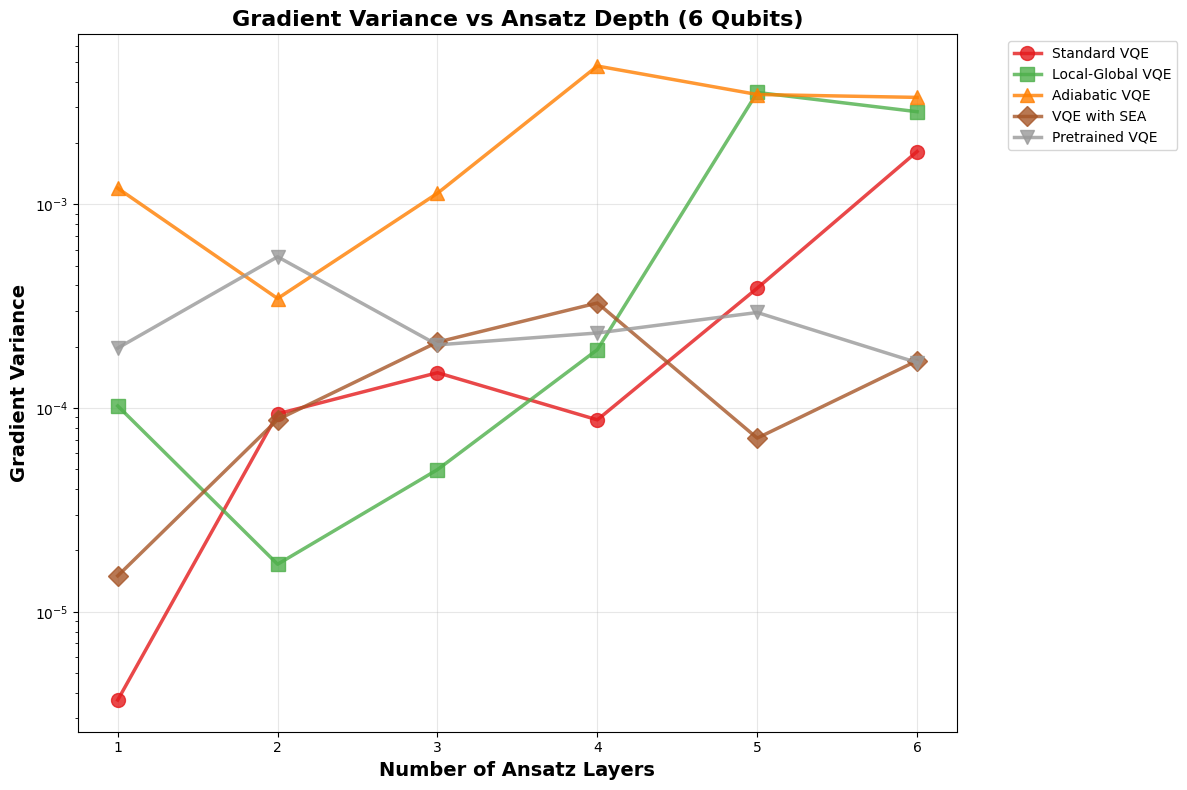


 Creating parameter scaling plot...
 Saved: ./layer_scaling_analysis/parameter_scaling.pdf


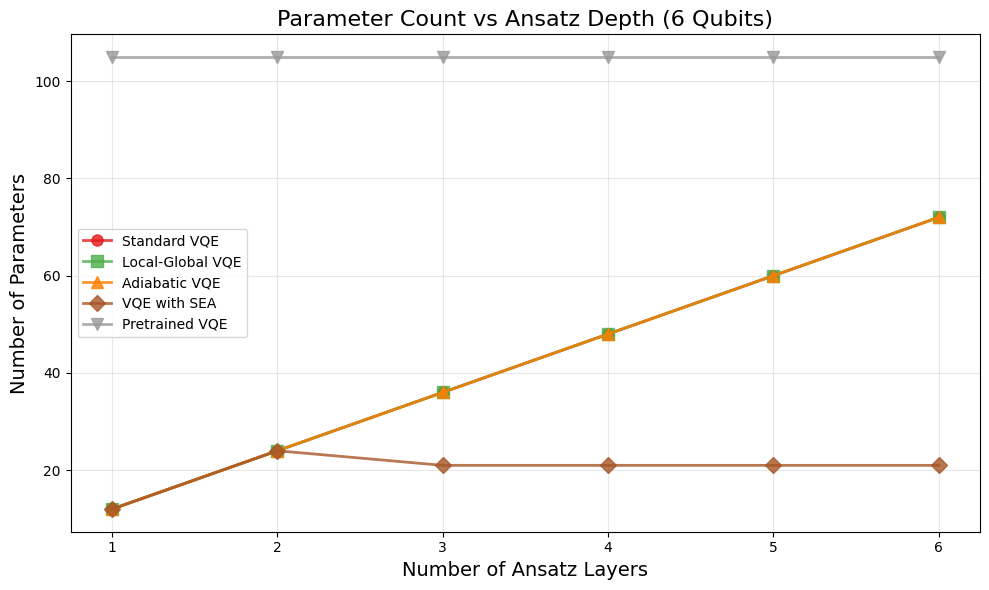


 Creating summary table...
 Saved: ./layer_scaling_analysis/layer_summary_table.csv

 LAYER VARIANCE SCALING SUMMARY (6 Qubits)
method      Adiabatic VQE  Local-Global VQE  Pretrained VQE  Standard VQE  VQE with SEA
num_layers                                                                             
1                1.20e-03          1.02e-04        1.97e-04      3.69e-06      1.50e-05
2                3.45e-04          1.71e-05        5.53e-04      9.37e-05      8.78e-05
3                1.13e-03          4.99e-05        2.04e-04      1.49e-04      2.11e-04
4                4.77e-03          1.93e-04        2.34e-04      8.75e-05      3.28e-04
5                3.46e-03          3.54e-03        2.94e-04      3.88e-04      7.12e-05
6                3.35e-03          2.85e-03        1.67e-04      1.82e-03      1.71e-04

 Analyzing parameter-variance correlations...
Parameter-Variance Correlations:
  Standard VQE: 0.760
  Local-Global VQE: 0.807
  Adiabatic VQE: 0.734
  VQE with SEA: 

In [5]:
# Plot variance scaling with layers
print(f"\n Creating layer variance scaling plot...")
plt.figure(figsize=(12, 8))

methods = df['method'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(methods)))
base_markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'h', '+', 'x']
markers = [base_markers[i % len(base_markers)] for i in range(len(methods))]

for i, (method, color) in enumerate(zip(methods, colors)):
    method_data = df[df['method'] == method].sort_values('num_layers')
    if len(method_data) > 0:
        plt.semilogy(method_data['num_layers'], 
                    method_data['gradient_variance'], 
                    marker=markers[i % len(markers)],
                    color=color,
                    label=method, 
                    markersize=10, 
                    linewidth=2.5,
                    alpha=0.8)

# # Add theoretical scaling lines
# layers_range = np.array(sorted(df['num_layers'].unique()))
# if len(layers_range) > 1:
#     # Exponential decay with layers (theoretical expectation)
#     for alpha in [0.5, 1.0, 1.5]:
#         theoretical = 1e-1 * np.exp(-alpha * layers_range)
#         plt.semilogy(layers_range, theoretical, '--', 
#                     alpha=0.4, color='gray', linewidth=1,
#                     label=f'Theory: exp(-{alpha}L)')

plt.xlabel('Number of Ansatz Layers', fontsize=14, fontweight='bold')
plt.ylabel('Gradient Variance', fontsize=14, fontweight='bold')
plt.title(f'Gradient Variance vs Ansatz Depth ({FIXED_NUM_QUBITS} Qubits)', 
          fontsize=16, fontweight='bold')
plt.xticks(sorted(df['num_layers'].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

variance_plot = os.path.join(PLOTS_DIR, 'layer_variance_scaling.pdf')
plt.savefig(variance_plot, dpi=300, bbox_inches='tight')
print(f" Saved: {variance_plot}")
plt.show()

# Plot parameter count vs layers
print(f"\n Creating parameter scaling plot...")
plt.figure(figsize=(10, 6))

for i, (method, color) in enumerate(zip(methods, colors)):
    method_data = df[df['method'] == method].sort_values('num_layers')
    if len(method_data) > 0:
        plt.plot(method_data['num_layers'], 
                method_data['num_parameters'], 
                marker=markers[i % len(markers)],
                color=color,
                label=method, 
                markersize=8, 
                linewidth=2,
                alpha=0.8)

plt.xlabel('Number of Ansatz Layers', fontsize=14)
plt.ylabel('Number of Parameters', fontsize=14)
plt.title(f'Parameter Count vs Ansatz Depth ({FIXED_NUM_QUBITS} Qubits)', fontsize=16)
plt.xticks(sorted(df['num_layers'].unique()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

param_plot = os.path.join(PLOTS_DIR, 'parameter_scaling.pdf')
plt.savefig(param_plot, dpi=300, bbox_inches='tight')
print(f" Saved: {param_plot}")
plt.show()

# Create summary table
print(f"\n Creating summary table...")
try:
    variance_pivot = df.pivot(index='num_layers', columns='method', values='gradient_variance')
    
    csv_file = os.path.join(PLOTS_DIR, 'layer_summary_table.csv')
    variance_pivot.to_csv(csv_file)
    print(f" Saved: {csv_file}")
    
    print(f"\n LAYER VARIANCE SCALING SUMMARY ({FIXED_NUM_QUBITS} Qubits)")
    print("=" * 80)
    print(variance_pivot.to_string(float_format='%.2e'))
    print("=" * 80)
    
except Exception as e:
    print(f" Summary table error: {e}")

# Correlation analysis
print(f"\n Analyzing parameter-variance correlations...")
if not df.empty:
    correlations = {}
    for method in df['method'].unique():
        method_data = df[df['method'] == method]
        if len(method_data) > 2:  # Need at least 3 points for correlation
            corr = np.corrcoef(method_data['num_parameters'], 
                             method_data['gradient_variance'])[0,1]
            correlations[method] = corr
    
    print("Parameter-Variance Correlations:")
    for method, corr in correlations.items():
        print(f"  {method}: {corr:.3f}")

# Final analysis
print(f"\n LAYER SCALING RESULTS:")
print("=" * 50)
successful_layers = len([r for r in all_results.values() if r is not None])
print(f"Successful layer configs: {successful_layers}/{len(LAYER_RANGE)}")
print(f"Fixed system size: {FIXED_NUM_QUBITS} qubits")

if not df.empty:
    # Best method at deepest layer
    deepest_layer = df['num_layers'].max()
    deepest_data = df[df['num_layers'] == deepest_layer]
    if len(deepest_data) > 0:
        best_method = deepest_data.loc[deepest_data['gradient_variance'].idxmin(), 'method']
        best_variance = deepest_data['gradient_variance'].min()
        print(f"Best method at {deepest_layer} layers: {best_method}")
        print(f"Lowest gradient variance: {best_variance:.2e}")
    
    # Check if variance increases with layers (barren plateau effect)
    print(f"\nBarren Plateau Analysis:")
    for method in df['method'].unique():
        method_data = df[df['method'] == method].sort_values('num_layers')
        if len(method_data) > 1:
            first_var = method_data.iloc[0]['gradient_variance']
            last_var = method_data.iloc[-1]['gradient_variance']
            ratio = last_var / first_var
            trend = "worsening" if ratio < 1 else "improving"
            print(f"  {method}: {ratio:.1f}x change ({trend})")

print("=" * 50)